In [ ]:
# Cell 1: imports and configuration

import os, re, random, time
import string
from collections import Counter
from itertools import product
from typing import List

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split

In [ ]:
# Config - GPU auto-detect
SEED = 42
DATA_DIR = "./data"   # place Fake.csv and True.csv here
USE_TITLE = True      # if True, use Title + Text
MAX_LEN = 300         # final model sequence length
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
MIN_FREQ = 2
BATCH_SIZE = 64
NUM_EPOCHS_FINAL = 20 # final training epochs
BASELINE_EPOCHS = 10  # Increased for convergence

# Device Configuration with fallback
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    USE_AMP = True  # Use mixed precision on GPU
    print(f"  GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"  CUDA devices: {torch.cuda.device_count()}")
    # cuDNN speed-ups for fixed-size sequences
    try:
        torch.backends.cudnn.benchmark = True
        print("  cuDNN benchmark: enabled")
    except Exception:
        pass
else:
    DEVICE = torch.device("cpu")
    USE_AMP = False  # No mixed precision on CPU
    print("⚠ No GPU detected - using CPU")
    print("  Training will be significantly slower")

# Ensure output directory
OUTPUT_DIR = os.path.join('.', 'output', 'lab6')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Reproducibility
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()

print(f"Device: {DEVICE} | Mixed Precision: {USE_AMP}")

✓ GPU detected: NVIDIA GeForce RTX 3050 Laptop GPU
  CUDA devices: 1
  cuDNN benchmark: enabled
Device: cuda | Mixed Precision: True


Dropped 6252 duplicates. New total: 38646
Total articles: 38646
------------------------------
Class counts (Normalized):
 label
0    0.548336
1    0.451664
Name: proportion, dtype: float64
------------------------------
Missing values:
 title        0
text         0
subject      0
date         0
label        0
text_full    0
dtype: int64


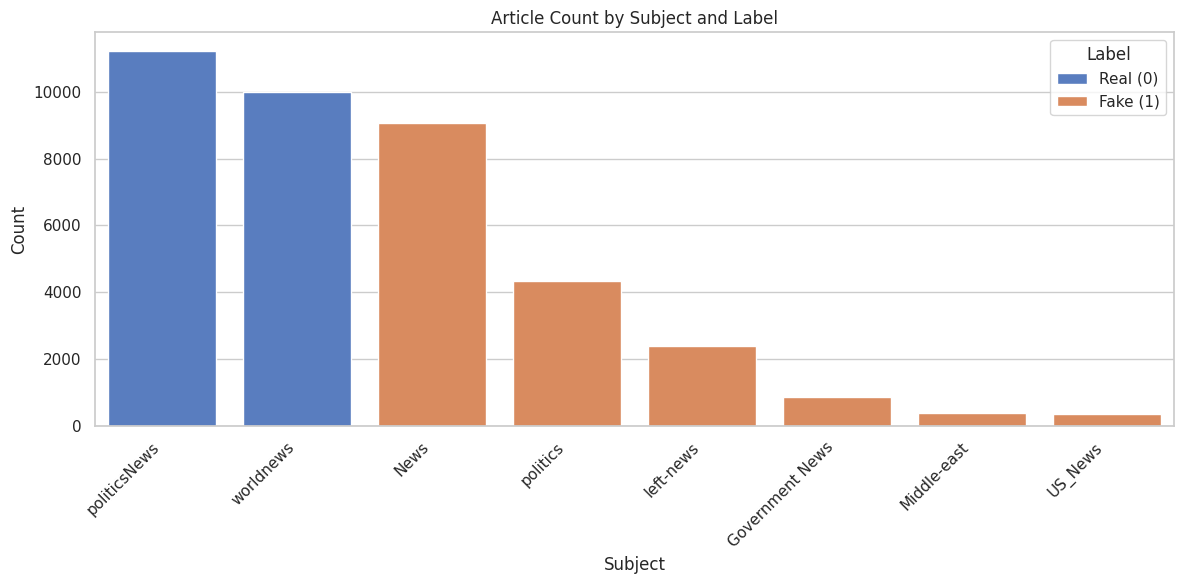

------------------------------
Invalid dates: 28056 (72.60%)


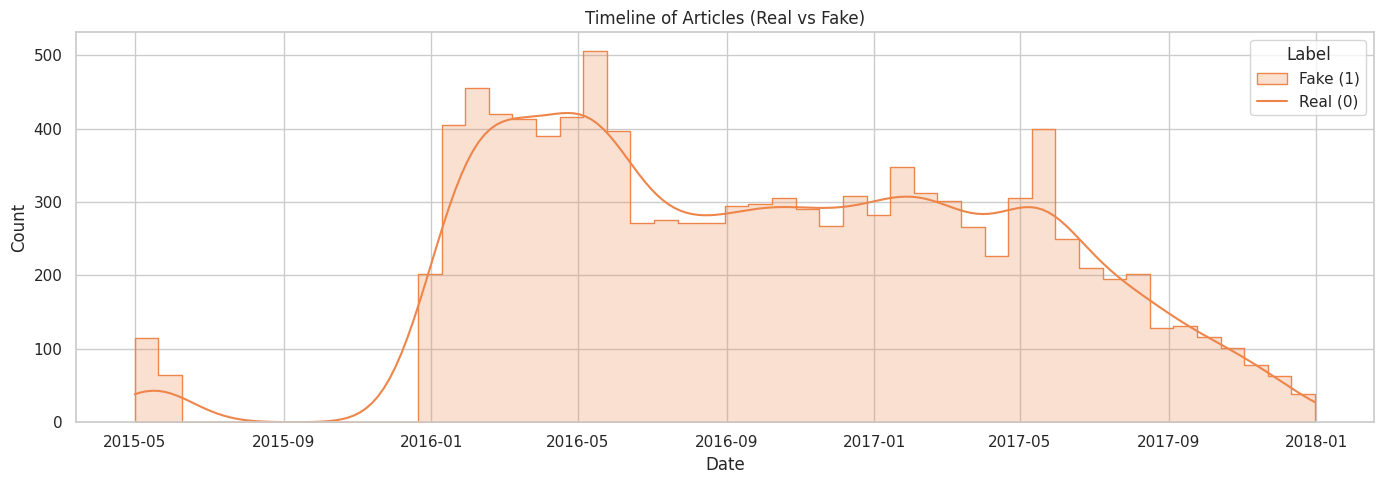

------------------------------
Length Statistics:
label                       0             1
title_len count  21191.000000  17455.000000
          mean       9.951253     14.317158
          std        1.698800      3.956364
          min        4.000000      1.000000
          25%        9.000000     12.000000
          50%       10.000000     14.000000
          75%       11.000000     16.000000
          max       20.000000     42.000000
text_len  count  21191.000000  17455.000000
          mean     394.782172    439.574277
          std      273.723269    355.373762
          min       29.000000      2.000000
          25%      157.500000    291.000000
          50%      368.000000    390.000000
          75%      533.000000    517.000000
          max     5181.000000   8148.000000


/tmp/ipykernel_141236/3475980376.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(['Real', 'Fake'])
/tmp/ipykernel_141236/3475980376.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['Real', 'Fake'])


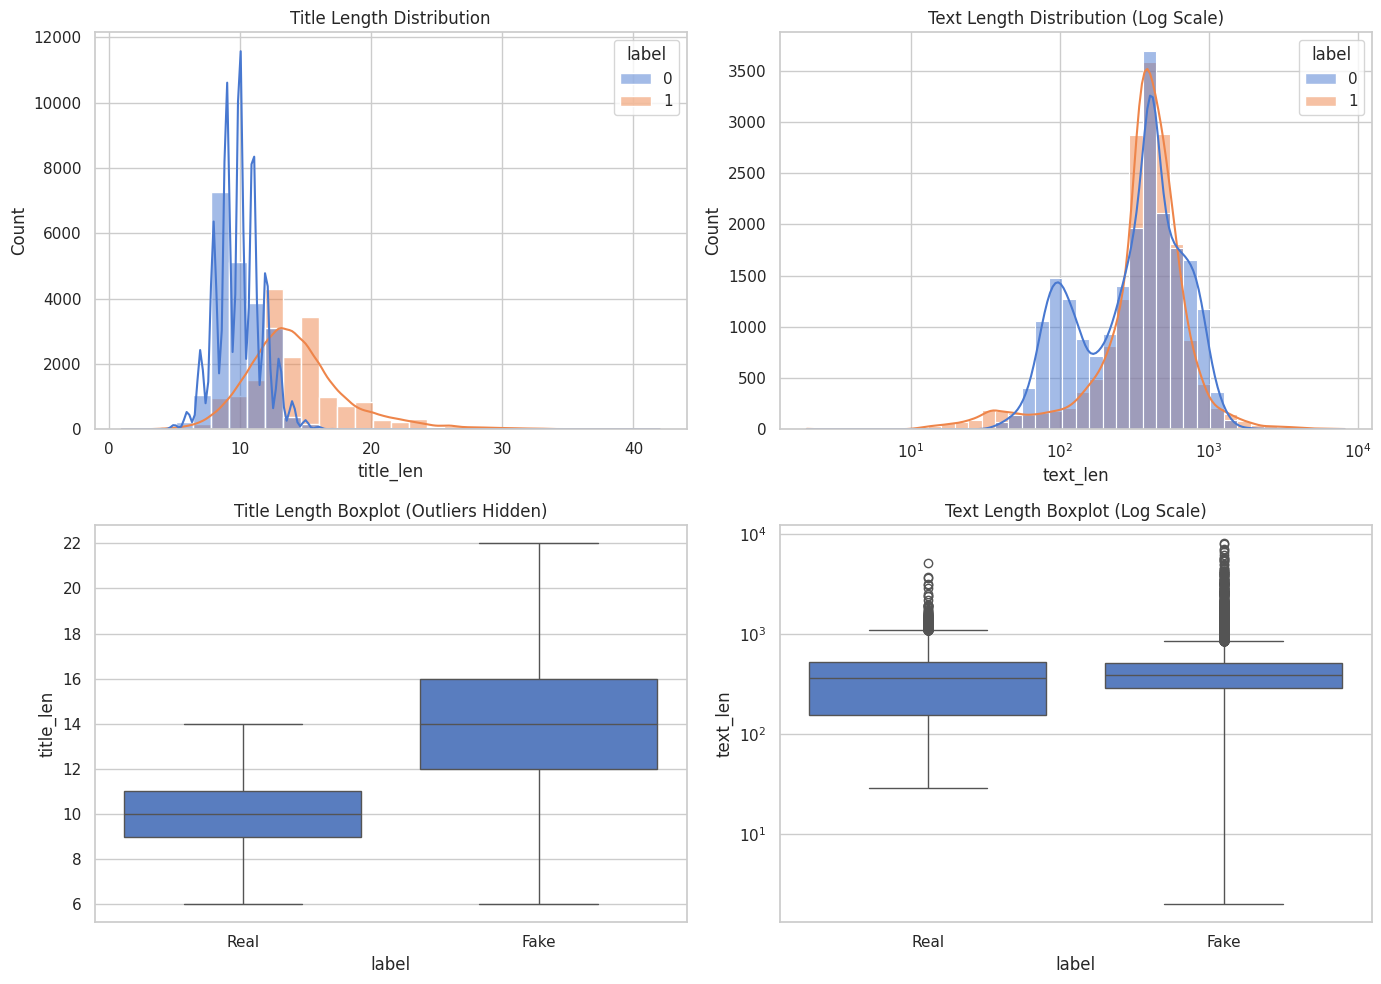

------------------------------
Top 10 words (Real): [('the', 22842), ('to', 12076), ('of', 9860), ('a', 9550), ('in', 8706), ('and', 8698), ('on', 5245), ('said', 4647), ('that', 4201), ('for', 3860)]
Top 10 words (Fake): [('the', 23146), ('to', 12779), ('of', 10341), ('and', 9823), ('a', 9419), ('in', 7406), ('that', 6508), ('s', 5569), ('is', 4793), ('for', 4063)]
Top 10 words (Fake): [('the', 23146), ('to', 12779), ('of', 10341), ('and', 9823), ('a', 9419), ('in', 7406), ('that', 6508), ('s', 5569), ('is', 4793), ('for', 4063)]


In [ ]:
#cell 2
sns.set_theme(style="whitegrid", palette="muted")

# --- Load and Prep Data ---
fake = pd.read_csv(os.path.join(DATA_DIR, "Fake.csv"))
true = pd.read_csv(os.path.join(DATA_DIR, "True.csv"))

fake['label'] = 1
true['label'] = 0

# Combine and shuffle
df = pd.concat([fake, true], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

# --- FIX: Drop duplicates based on text content ---
initial_len = len(df)
df.drop_duplicates(subset=['text'], inplace=True)
print(f"Dropped {initial_len - len(df)} duplicates. New total: {len(df)}")
# Create full text column
if USE_TITLE:
    df['text_full'] = (df['title'].fillna('') + ' ' + df['text'].fillna('')).astype(str)
else:
    df['text_full'] = df['text'].fillna('').astype(str)

# --- Basic Info ---
print("Total articles:", len(df))
print("-" * 30)
print("Class counts (Normalized):\n", df['label'].value_counts(normalize=True))
print("-" * 30)
print("Missing values:\n", df.isnull().sum())

# --- 1. Subject Analysis ---
plt.figure(figsize=(12, 6))
# Using a countplot is often more "reasonable" than a stacked bar because 
# it shows the massive volume difference between categories like 'politicsNews' vs others.
sns.countplot(data=df, x='subject', hue='label', order=df['subject'].value_counts().index)
plt.title('Article Count by Subject and Label')
plt.xlabel('Subject')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Label', labels=['Real (0)', 'Fake (1)'])
plt.tight_layout()
plt.show()

# --- 2. Date Analysis ---
# Coerce errors to handle the messy dates often found in Fake news datasets
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')

# Check how many dates failed parsing (common feature in fake news)
print("-" * 30)
print(f"Invalid dates: {df['date_parsed'].isnull().sum()} ({(df['date_parsed'].isnull().sum()/len(df))*100:.2f}%)")

plt.figure(figsize=(14, 5))
# Histplot with 'kde' gives a smoother view of the timeline
sns.histplot(data=df, x='date_parsed', hue='label', bins=50, kde=True, element="step")
plt.title('Timeline of Articles (Real vs Fake)')
plt.xlabel('Date')
plt.legend(title='Label', labels=['Fake (1)', 'Real (0)']) # Adjust labels based on plot order
plt.tight_layout()
plt.show()

# --- 3. Length Analysis ---
df['title_len'] = df['title'].astype(str).str.split().apply(len)
df['text_len'] = df['text_full'].str.split().apply(len)

# Print stats
print("-" * 30)
print("Length Statistics:")
print(df.groupby('label')[['title_len', 'text_len']].describe().T)

# Create a 2x2 Grid for Length Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# A. Title Length Histogram
sns.histplot(data=df, x='title_len', hue='label', kde=True, ax=axes[0, 0], bins=30)
axes[0, 0].set_title('Title Length Distribution')

# B. Text Length Histogram (Log Scale)
# Text length often follows a power law. A log scale makes this readable.
sns.histplot(data=df, x='text_len', hue='label', kde=True, ax=axes[0, 1], bins=40, log_scale=True)
axes[0, 1].set_title('Text Length Distribution (Log Scale)')

# C. Title Length Boxplot
sns.boxplot(data=df, x='label', y='title_len', ax=axes[1, 0], showfliers=False) # Hiding extreme outliers for clarity
axes[1, 0].set_title('Title Length Boxplot (Outliers Hidden)')
axes[1, 0].set_xticklabels(['Real', 'Fake'])

# D. Text Length Boxplot (Log Scale on Y)
sns.boxplot(data=df, x='label', y='text_len', ax=axes[1, 1])
axes[1, 1].set_yscale('log') # Log scale is crucial for "reasonable" text length boxplots
axes[1, 1].set_title('Text Length Boxplot (Log Scale)')
axes[1, 1].set_xticklabels(['Real', 'Fake'])

plt.tight_layout()
plt.show()

# --- 4. Vocabulary Check ---
def get_top_words(texts, n=20):
    # Simple cleaner: keep only letters
    all_text = ' '.join(texts).lower()
    all_text = re.sub(r'[^a-z\s]', '', all_text) 
    words = all_text.split()
    return Counter(words).most_common(n)

print("-" * 30)
# Calculate top words for a subset to save time
real_top = get_top_words(df[df['label'] == 0]['text_full'].head(1000), n=10)
fake_top = get_top_words(df[df['label'] == 1]['text_full'].head(1000), n=10)

print(f"\n{'TOP 10 WORDS COMPARISON':^45}")
print("=" * 45)
print(f"{'RANK':<5} | {'REAL NEWS':<15} | {'FAKE NEWS':<15}")
print("-" * 45)

for i in range(10):
    real_word = f"{real_top[i][0]} ({real_top[i][1]})"
    fake_word = f"{fake_top[i][0]} ({fake_top[i][1]})"
    print(f"{i+1:<5} | {real_word:<15} | {fake_word:<15}")

print("=" * 45)

In [ ]:
# Cell 3: fast regex cleaner + tokenizer (no NLTK)
def clean_text(text: str) -> str:
    if text is None: return ""
    text = text.lower()
    
    # --- FIX: Remove publisher signature leakage ---
    text = re.sub(r'^.*?\(reuters\)\s*-?\s*', '', text)  # "washington (reuters) -"
    text = re.sub(r'\breuters\b', '', text)              # "reuters"
    text = re.sub(r'\b(?:by|via)\s+(?:reuters|ap|afp)\b', '', text) # "by reuters"
    # -----------------------------------------------

    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)   # remove urls
    text = re.sub(r'\S+@\S+', ' ', text)                   # remove emails
    text = re.sub(r'[^a-z0-9\s\.\,\!\?\'\-]', ' ', text)   # keep basic punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize(text: str) -> List[str]:
    # simple regex tokenization
    return re.findall(r"[a-z0-9']+|-|[^\s]", text.lower())

# apply cleaning + tokenization
df['clean'] = df['text_full'].astype(str).apply(clean_text)
df['tokens'] = df['clean'].apply(tokenize)

# Print tokens as a clean table
print(f"\nExample Tokens (First 20):")
print("-" * 30)
print(f"{'Index':<8} | {'Token'}")
print("-" * 30)
for i, token in enumerate(df['tokens'].iloc[0][:20]):
    print(f"{i:<8} | {token}")
print("-" * 30)

Example tokens: ['ben', 'stein', 'calls', 'out', '9th', 'circuit', 'court', 'committed', 'a', 'coup', 'd', 'tat', 'against', 'the', 'constitution', '21st', 'century', 'wire', 'says', 'ben']


In [ ]:
# Cell 4: Vocab build and numericalization
class Vocab:
    def __init__(self, min_freq=MIN_FREQ, pad_token=PAD_TOKEN, unk_token=UNK_TOKEN):
        self.min_freq = min_freq
        self.pad_token = pad_token
        self.unk_token = unk_token
        self.freqs = Counter()
        self.stoi = {}
        self.itos = []

    def build(self, token_lists):
        for toks in token_lists:
            self.freqs.update(toks)
        common = [tok for tok, ct in self.freqs.most_common() if ct >= self.min_freq]
        self.itos = [self.pad_token, self.unk_token] + common
        self.stoi = {tok: i for i, tok in enumerate(self.itos)}
        self.pad_index = self.stoi[self.pad_token]
        self.unk_index = self.stoi[self.unk_token]
        print("Vocab size (incl pad/unk):", len(self.itos))

    def numericalize(self, tokens, max_len=MAX_LEN):
        ids = [self.stoi.get(t, self.unk_index) for t in tokens]
        if len(ids) >= max_len:
            return ids[:max_len]
        return ids + [self.pad_index] * (max_len - len(ids))
    
    def __len__(self):
        return len(self.itos)
    
    def get(self, token):
        return self.stoi.get(token, self.unk_index)

# NOTE: Vocab will be built AFTER data split to prevent leakage


In [ ]:
# Cell 5: Data Splitting and DataLoader Setup

# --- 1. Split Helper Function ---
def split_df(df, train_frac=0.8, val_frac=0.1, seed=SEED):
    n = len(df)
    df_shuf = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    train_end = int(n * train_frac)
    val_end = train_end + int(n * val_frac)
    return (df_shuf.iloc[:train_end].reset_index(drop=True),
            df_shuf.iloc[train_end:val_end].reset_index(drop=True),
            df_shuf.iloc[val_end:].reset_index(drop=True))

# --- 2. Leakage Prevention ---
print("PRE-PROCESSING: Removing metadata columns (subject, date)...")
# Subject and date columns contain strong signals from original dataset sources
df_clean = df.drop(columns=['subject', 'date', 'date_parsed'], errors='ignore')

# --- 3. Execute Split ---
train_df, val_df, test_df = split_df(df_clean, 0.8, 0.1)

# --- 4. Beautiful Split Report ---
total = len(df_clean)
print("\n" + "="*60)
print(f"{'DATASET SPLIT SUMMARY':^60}")
print("="*60)
print(f"{'SET':<10} | {'SAMPLES':>8} | {'PERCENT':>7} | {'LABEL DIST (0:Real, 1:Fake)'}")
print("-" * 60)
print(f"{'Train':<10} | {len(train_df):>8} | {len(train_df)/total*100:>6.1f}% | {train_df['label'].value_counts().to_dict()}")
print(f"{'Validation':<10} | {len(val_df):>8} | {len(val_df)/total*100:>6.1f}% | {val_df['label'].value_counts().to_dict()}")
print(f"{'Test':<10} | {len(test_df):>8} | {len(test_df)/total*100:>6.1f}% | {test_df['label'].value_counts().to_dict()}")
print("-" * 60)

# --- 5. Build Vocabulary (Strictly on Train Data) ---
print(f"\n{'VOCABULARY BUILD':^60}")
print("-" * 60)
print("Building vocabulary from TRAINING data only...", end=" ")
vocab = Vocab(min_freq=MIN_FREQ)
vocab.build(train_df['tokens'].tolist())
print(f"Done.")
print(f"Total Unique Tokens: {len(vocab):,}")
print(f"Special Tokens     : {vocab.get('<pad>')}(pad), {vocab.get('<unk>')}(unk)")

# --- 6. Numericalization ---
print("\nConverting text to indices...", end=" ")
train_df['indices'] = train_df['tokens'].apply(lambda t: vocab.numericalize(t, max_len=MAX_LEN))
val_df['indices'] = val_df['tokens'].apply(lambda t: vocab.numericalize(t, max_len=MAX_LEN))
test_df['indices'] = test_df['tokens'].apply(lambda t: vocab.numericalize(t, max_len=MAX_LEN))
print("Done.")

# --- 7. Class Weights (For Imbalanced Loss) ---
train_labels = train_df['label'].values
class_counts = np.bincount(train_labels.astype(int))
class_weights = len(train_labels) / (len(class_counts) * class_counts)

print(f"\n{'CLASS WEIGHT CONFIGURATION':^60}")
print("-" * 60)
print(f"Real News (0) : {class_counts[0]:>5} samples -> Weight: {class_weights[0]:.4f}")
print(f"Fake News (1) : {class_counts[1]:>5} samples -> Weight: {class_weights[1]:.4f}")

# --- 8. Dataset & Loader Construction ---
class NewsDataset(Dataset):
    def __init__(self, indices_list, labels):
        self.indices = indices_list
        self.labels = labels
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        return torch.tensor(self.indices[idx], dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.float)

# Determine if we should pin memory (Faster data transfer to GPU)
pin_mem = (DEVICE.type == 'cuda')

# Create DataLoaders
train_loader = DataLoader(NewsDataset(train_df['indices'].tolist(), train_df['label'].tolist()), 
                          batch_size=BATCH_SIZE, shuffle=True, pin_memory=pin_mem)
val_loader = DataLoader(NewsDataset(val_df['indices'].tolist(), val_df['label'].tolist()), 
                        batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin_mem)
test_loader = DataLoader(NewsDataset(test_df['indices'].tolist(), test_df['label'].tolist()), 
                         batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin_mem)

print("\n" + "="*60)
print(f"READY FOR TRAINING on {DEVICE}")
print(f"Batch Size: {BATCH_SIZE} | Pin Memory: {pin_mem}")
print("="*60)

PRE-PROCESSING: Removing metadata columns (subject, date)...

                   DATASET SPLIT SUMMARY                    
SET        |  SAMPLES | PERCENT | LABEL DIST (0:Real, 1:Fake)
------------------------------------------------------------
Train      |    30916 |   80.0% | {0: 16964, 1: 13952}
Validation |     3864 |   10.0% | {0: 2107, 1: 1757}
Test       |     3866 |   10.0% | {0: 2120, 1: 1746}
------------------------------------------------------------

                      VOCABULARY BUILD                      
------------------------------------------------------------
Building vocabulary from TRAINING data only... 
                   DATASET SPLIT SUMMARY                    
SET        |  SAMPLES | PERCENT | LABEL DIST (0:Real, 1:Fake)
------------------------------------------------------------
Train      |    30916 |   80.0% | {0: 16964, 1: 13952}
Validation |     3864 |   10.0% | {0: 2107, 1: 1757}
Test       |     3866 |   10.0% | {0: 2120, 1: 1746}
----------------

In [ ]:
# Cell 6: models (use CPU-friendly settings)
class SimpleRNNClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, dropout=0.2, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(input_size=emb_dim, hidden_size=hidden_dim, num_layers=num_layers,
                          batch_first=True, nonlinearity='tanh', dropout=(dropout if num_layers>1 else 0.0))
        self.fc = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        emb = self.embedding(x)
        out, h_n = self.rnn(emb)
        last = h_n[-1]
        logits = self.fc(last).squeeze(1)
        return logits

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, bidirectional=False, dropout=0.2, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(input_size=emb_dim, hidden_size=hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=bidirectional, dropout=(dropout if num_layers>1 else 0.0))
        factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim*factor, 1)
        self.bidirectional = bidirectional
    def forward(self, x):
        emb = self.embedding(x)
        out, (h_n, c_n) = self.lstm(emb)
        if self.bidirectional:
            last = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            last = h_n[-1]
        logits = self.fc(last).squeeze(1)
        return logits


In [ ]:
# Cell 7: training and evaluation helpers
# --- FIX: Add class weights to loss function for imbalanced data ---
# Calculate pos_weight for BCEWithLogitsLoss (ratio of negative to positive samples)
train_labels_tensor = torch.tensor(train_df['label'].values, dtype=torch.float)
n_pos = train_labels_tensor.sum().item()
n_neg = len(train_labels_tensor) - n_pos
pos_weight = torch.tensor([n_neg / n_pos]).to(DEVICE)
print(f"Using pos_weight={pos_weight.item():.3f} for BCEWithLogitsLoss (n_neg={n_neg}, n_pos={n_pos})")
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Mixed precision scaler (used only if USE_AMP and CUDA)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

def train_epoch(model, loader, optimizer, device=DEVICE, grad_clip=5.0):
    model.train()
    losses = []
    for x,y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        if USE_AMP:
            # Use the new autocast API to avoid FutureWarning
            with torch.amp.autocast('cuda'):
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses)) if losses else 0.0

def evaluate_model(model, loader, device=DEVICE):
    model.eval()
    preds, probs, trues = [], [], []
    losses = []
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model(x)
            loss = criterion(logits, y)
            p = torch.sigmoid(logits).cpu().numpy()
            preds.extend((p>=0.5).astype(int).tolist())
            probs.extend(p.tolist())
            trues.extend(y.cpu().numpy().astype(int).tolist())
            losses.append(loss.item())
    metrics = {
        'loss': float(np.mean(losses)) if losses else 0.0,
        'acc': accuracy_score(trues, preds),
        'precision': precision_score(trues, preds, zero_division=0),
        'recall': recall_score(trues, preds, zero_division=0),
        'f1': f1_score(trues, preds, zero_division=0),
        'roc_auc': float(roc_auc_score(trues, probs)) if len(set(trues))>1 else float('nan'),
        'preds': np.array(preds),
        'probs': np.array(probs),
        'trues': np.array(trues)
    }
    return metrics

def train_model(model, train_loader, val_loader, epochs=4, lr=1e-3, device=DEVICE, verbose=True):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_roc': []}
    best_f1 = -1.0
    best_state = None
    for epoch in range(1, epochs+1):
        t0 = time.time()
        tr_loss = train_epoch(model, train_loader, opt, device)
        val = evaluate_model(model, val_loader, device)
        history['train_loss'].append(tr_loss); history['val_loss'].append(val['loss']);
        history['val_f1'].append(val['f1']); history['val_roc'].append(val['roc_auc'])
        if val['f1'] > best_f1:
            best_f1 = val['f1']
            best_state = {k:v.cpu() for k,v in model.state_dict().items()}
        if verbose:
            print(f"Epoch {epoch}/{epochs} train_loss={tr_loss:.4f} val_loss={val['loss']:.4f} val_f1={val['f1']:.4f} time={(time.time()-t0):.1f}s")
    if best_state: model.load_state_dict(best_state)
    return model, history


Using pos_weight=1.216 for BCEWithLogitsLoss (n_neg=16964.0, n_pos=13952.0)


/tmp/ipykernel_141236/1197485246.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


In [ ]:
# Cell 8: plotting helpers (required plots) - SEABORN VERSION
def plot_training(history, title="Training"):
    # Convert history dict to DataFrame for easier sns plotting
    epochs = list(range(1, len(history['train_loss']) + 1))
    
    # Create two subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Loss Plot
    sns.lineplot(x=epochs, y=history['train_loss'], label='Train Loss', ax=axes[0], marker='o')
    sns.lineplot(x=epochs, y=history['val_loss'], label='Val Loss', ax=axes[0], marker='o')
    axes[0].set_title(f'{title} Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True)
    
    # 2. Metrics Plot (F1 & ROC)
    sns.lineplot(x=epochs, y=history['val_f1'], label='Val F1', ax=axes[1], marker='o', color='green')
    sns.lineplot(x=epochs, y=history['val_roc'], label='Val ROC', ax=axes[1], marker='o', color='purple')
    axes[1].set_title(f'{title} Metrics')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Score')
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(trues, preds, title="Confusion Matrix"):
    cm = confusion_matrix(trues, preds)
    plt.figure(figsize=(4, 3))
    
    # sns.heatmap is perfect for confusion matrices
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Real (0)', 'Fake (1)'],
                yticklabels=['Real (0)', 'Fake (1)'])
    
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

def plot_roc(trues, probs, title='ROC Curve'):
    fpr, tpr, _ = roc_curve(trues, probs)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6, 4))
    
    # Plot the ROC curve
    sns.lineplot(x=fpr, y=tpr, label=f'AUC = {roc_auc:.4f}', linewidth=2)
    
    # Plot the random guess line
    plt.plot([0, 1], [0, 1], 'k--', linestyle='--')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()

Starting Baseline Training on cuda for 10 epochs...
Epoch 1/10 train_loss=0.4985 val_loss=0.4662 val_f1=0.8304 time=8.0s
Epoch 1/10 train_loss=0.4985 val_loss=0.4662 val_f1=0.8304 time=8.0s
Epoch 2/10 train_loss=0.4329 val_loss=0.3435 val_f1=0.8934 time=7.6s
Epoch 2/10 train_loss=0.4329 val_loss=0.3435 val_f1=0.8934 time=7.6s
Epoch 3/10 train_loss=0.2765 val_loss=0.2454 val_f1=0.9352 time=7.3s
Epoch 3/10 train_loss=0.2765 val_loss=0.2454 val_f1=0.9352 time=7.3s
Epoch 4/10 train_loss=0.1464 val_loss=0.1245 val_f1=0.9581 time=6.6s
Epoch 4/10 train_loss=0.1464 val_loss=0.1245 val_f1=0.9581 time=6.6s
Epoch 5/10 train_loss=0.0990 val_loss=0.1499 val_f1=0.9593 time=6.9s
Epoch 5/10 train_loss=0.0990 val_loss=0.1499 val_f1=0.9593 time=6.9s
Epoch 6/10 train_loss=0.0756 val_loss=0.1179 val_f1=0.9764 time=7.0s
Epoch 6/10 train_loss=0.0756 val_loss=0.1179 val_f1=0.9764 time=7.0s
Epoch 7/10 train_loss=0.0689 val_loss=0.1242 val_f1=0.9769 time=7.6s
Epoch 7/10 train_loss=0.0689 val_loss=0.1242 val_f1

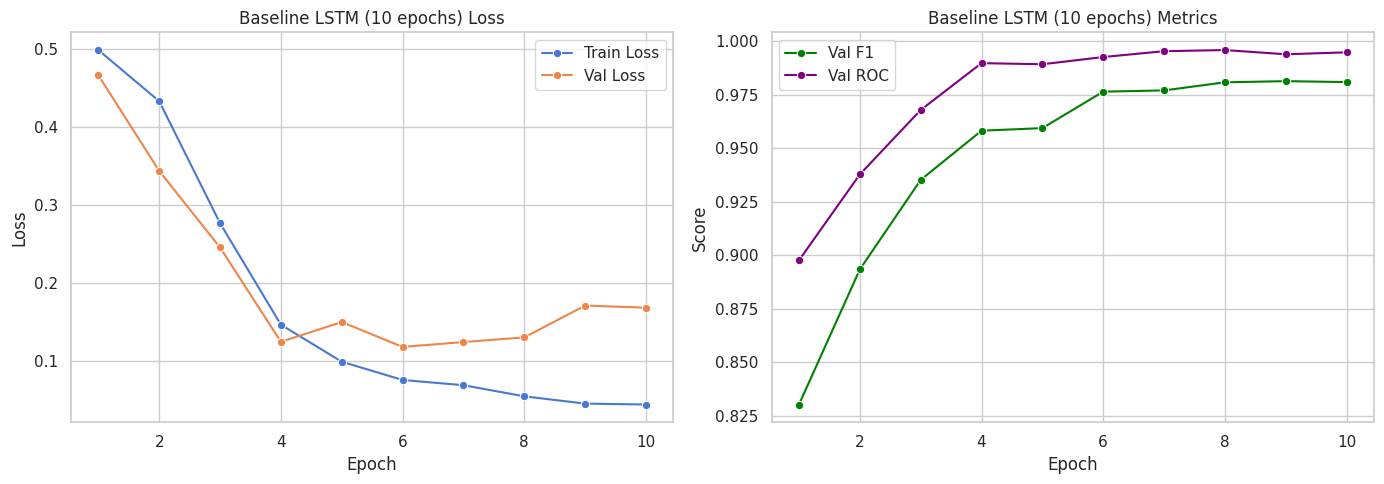

------------------------------
Baseline Val  F1: 0.9813 | ROC: 0.9938
Baseline Test F1: 0.9847 | ROC: 0.9952
------------------------------


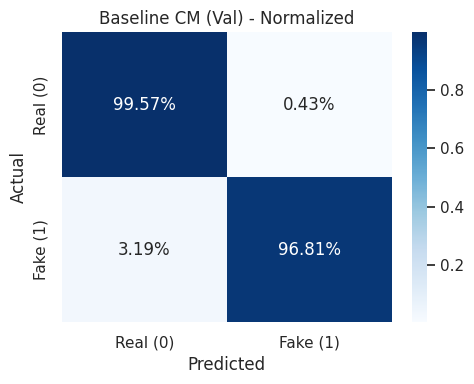

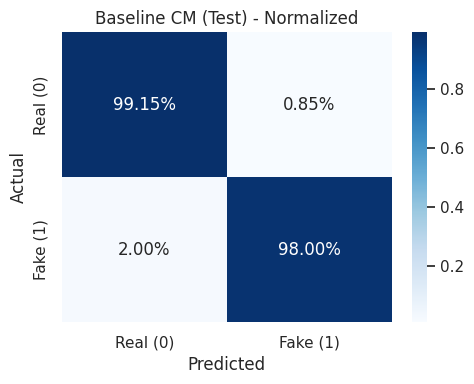

/tmp/ipykernel_141236/632186175.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', linestyle='--')


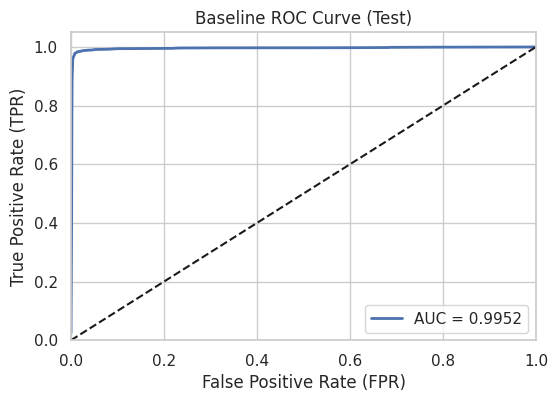

In [ ]:
#cell 9
print(f"Starting Baseline Training on {DEVICE} for {BASELINE_EPOCHS} epochs...")

# 2. Initialize Model
vocab_size = len(vocab.itos)
baseline = LSTMClassifier(vocab_size=vocab_size, emb_dim=100, hidden_dim=128, 
                          num_layers=1, bidirectional=False, dropout=0.2, 
                          pad_idx=vocab.pad_index)

# 3. Train (Full duration)
baseline, hist = train_model(baseline, train_loader, val_loader, 
                             epochs=BASELINE_EPOCHS, lr=1e-3, device=DEVICE, verbose=True)

# 4. Plot Training Curves
plot_training(hist, title=f"Baseline LSTM ({BASELINE_EPOCHS} epochs)")

# 5. Evaluate
val_res = evaluate_model(baseline, val_loader, DEVICE)
test_res = evaluate_model(baseline, test_loader, DEVICE)

print("-" * 30)
print(f"Baseline Val  F1: {val_res['f1']:.4f} | ROC: {val_res['roc_auc']:.4f}")
print(f"Baseline Test F1: {test_res['f1']:.4f} | ROC: {test_res['roc_auc']:.4f}")
print("-" * 30)

# 6. Diagnostics (Seaborn Style)
sns.set_theme(style="whitegrid")

def plot_confusion_matrix_normalized(y_true, y_pred, title='Confusion Matrix'):
    """Plots a normalized confusion matrix (percentage based)"""
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2%', 
                xticklabels=['Real (0)','Fake (1)'], 
                yticklabels=['Real (0)','Fake (1)'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Plot Confusion Matrices
plot_confusion_matrix_normalized(val_res['trues'], val_res['preds'], 
                                 title='Baseline CM (Val) - Normalized')
plot_confusion_matrix_normalized(test_res['trues'], test_res['preds'], 
                                 title='Baseline CM (Test) - Normalized')

# Plot ROC
if 'plot_roc' in globals():
    plot_roc(test_res['trues'], test_res['probs'], title='Baseline ROC Curve (Test)')

In [ ]:
# Cell 10: hyperparameter grid (exactly as you wanted) and fast search wrapper
grid = {
    'model': ['lstm', 'rnn'],
    'emb_dim': [50, 100],
    'hidden_dim': [64, 128],
    'num_layers': [1, 2],
    'bidirectional': [False, True],
    'dropout': [0.0, 0.2],
    'lr': [1e-3, 5e-4]
}

# Fast-search helper: uses a small fraction of training data + shorter sequences + fewer epochs
def build_short_indices(df_tokens, vocab, short_len):
    return [vocab.numericalize(toks, max_len=short_len) for toks in df_tokens]

def hp_search(grid, max_trials=8, epochs=2, short_frac=0.12, short_len=120, verbose: bool = True):
    """
    grid: same shape as your original
    max_trials: number of configs to try (keeps your call signature)
    epochs: epochs per trial (small)
    short_frac: fraction of train/val used for fast search
    short_len: sequence length used during search
    verbose: when False, suppress per-config logging
    """
    # prepare small data indices
    n_train = int(len(train_df) * short_frac)
    n_val = int(len(val_df) * short_frac)
    # build short-index dataset (for entire df tokens but with truncated length)
    short_indices_all = build_short_indices(df['tokens'].tolist(), vocab, short_len)
    # small split slices
    train_inds_small = short_indices_all[:n_train]
    val_inds_small = short_indices_all[len(train_df):len(train_df)+n_val]  # use slice after train_df in shuffled df
    train_labels_small = train_df['label'].tolist()[:n_train]
    val_labels_small = val_df['label'].tolist()[:n_val]

    # prepare config list
    keys = list(grid.keys())
    all_cfgs = [dict(zip(keys, vals)) for vals in product(*(grid[k] for k in keys))]
    random.shuffle(all_cfgs)
    all_cfgs = all_cfgs[:max_trials]

    results = []
    for cfg in all_cfgs:
        # build model
        if cfg['model'] == 'rnn':
            m = SimpleRNNClassifier(vocab_size=len(vocab.itos),
                                    emb_dim=cfg['emb_dim'],
                                    hidden_dim=cfg['hidden_dim'],
                                    num_layers=cfg['num_layers'],
                                    dropout=cfg['dropout'],
                                    pad_idx=vocab.pad_index)
        else:
            m = LSTMClassifier(vocab_size=len(vocab.itos),
                               emb_dim=cfg['emb_dim'],
                               hidden_dim=cfg['hidden_dim'],
                               num_layers=cfg['num_layers'],
                               bidirectional=cfg['bidirectional'],
                               dropout=cfg['dropout'],
                               pad_idx=vocab.pad_index)
        # create small loaders
        tr_loader_small = DataLoader(NewsDataset(train_inds_small, train_labels_small), batch_size=BATCH_SIZE, shuffle=True)
        val_loader_small = DataLoader(NewsDataset(val_inds_small, val_labels_small), batch_size=BATCH_SIZE, shuffle=False)

        # train quickly
        m, hist = train_model(m, tr_loader_small, val_loader_small, epochs=epochs, lr=cfg['lr'], device=DEVICE, verbose=False)
        val_res = evaluate_model(m, val_loader_small, DEVICE)

        results.append({'config': cfg, 'val_f1': val_res['f1'], 'val_roc': val_res['roc_auc'], 'val_loss': val_res['loss'], 'n_params': sum(p.numel() for p in m.parameters())})
        if verbose:
            print(f"CFG: {cfg} | val_f1: {val_res['f1']:.4f} | val_roc: {val_res['roc_auc']:.4f} | params: {results[-1]['n_params']}")
    return results

# Run the search (this is the line you had previously)
# (Silenced external print; pass verbose=False to suppress internal logs)
# print("Starting hyperparameter search (fast mode, small trials) ...")
hp_results = hp_search(grid, max_trials=8, epochs=2, short_frac=0.12, short_len=120, verbose=False)

# Summarize
hp_summary = []
for r in hp_results:
    cfg = r['config'].copy()
    cfg.update({'val_f1': r['val_f1'], 'val_roc': r['val_roc'], 'n_params': r['n_params'], 'val_loss': r['val_loss']})
    hp_summary.append(cfg)
hp_df = pd.DataFrame(hp_summary).sort_values(by='val_f1', ascending=False).reset_index(drop=True)
display(hp_df)
hp_df.to_csv(os.path.join(OUTPUT_DIR, "hp_search_summary.csv"), index=False)


,model,emb_dim,hidden_dim,num_layers,bidirectional,dropout,lr,val_f1,val_roc,n_params,val_loss
0,lstm,50,64,2,False,0.0,0.0005,0.614221,0.505463,3139641,0.762052
1,lstm,100,128,1,False,0.0,0.0005,0.554913,0.531212,6271089,0.760132
2,rnn,50,64,2,True,0.0,0.0010,0.549372,0.494924,3092409,0.765368
3,lstm,50,128,1,False,0.0,0.0010,0.549323,0.531127,3168889,0.762390
4,rnn,100,64,1,True,0.2,0.0005,0.536383,0.510492,6163889,0.765322
5,lstm,100,128,2,True,0.2,0.0010,0.523719,0.462938,6784241,0.764891
6,rnn,100,64,1,True,0.2,0.0010,0.522484,0.525513,6163889,0.767957
7,rnn,50,128,2,True,0.0,0.0010,0.520000,0.487328,3132793,0.770895


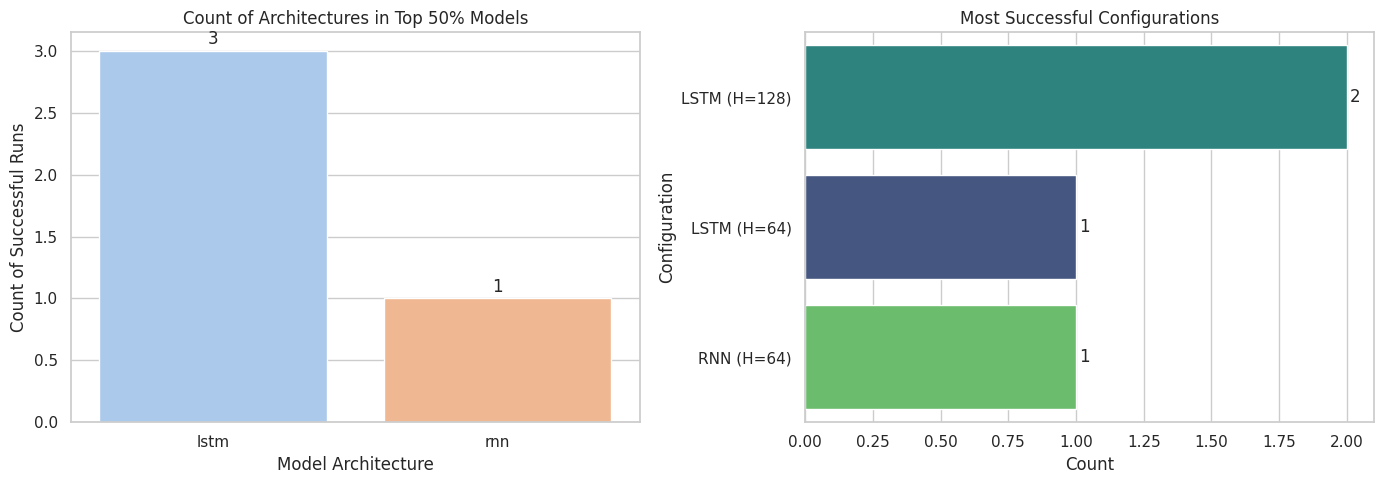

In [ ]:
#cell 11
def plot_top_performers_sns(hp_df):
    # 1. Filter for "Winners" (Top 50% of models based on F1 Score)
    median_score = hp_df['val_f1'].median()
    winners = hp_df[hp_df['val_f1'] > median_score].copy()
    
    # Create a nice label for the plot
    winners['label'] = winners.apply(lambda x: f"{x['model'].upper()} (H={x['hidden_dim']})", axis=1)

    # 2. Setup Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Plot 1: Architecture Dominance (The "Pie" replacement) ---
    # Shows count of LSTM vs RNN in the winner's circle
    sns.countplot(data=winners, x='model', palette='pastel', ax=axes[0], hue='model', legend=False)
    
    # Add count labels on top
    for container in axes[0].containers:
        axes[0].bar_label(container, padding=2)
        
    axes[0].set_title("Count of Architectures in Top 50% Models")
    axes[0].set_xlabel("Model Architecture")
    axes[0].set_ylabel("Count of Successful Runs")

    # --- Plot 2: Full Configuration Breakdown ---
    # Shows exactly which configs appear most often in the top half
    sns.countplot(data=winners, y='label', palette='viridis', ax=axes[1], hue='label', legend=False, order=winners['label'].value_counts().index)
    
    # Add count labels
    for container in axes[1].containers:
        axes[1].bar_label(container, padding=2)
        
    axes[1].set_title("Most Successful Configurations")
    axes[1].set_xlabel("Count")
    axes[1].set_ylabel("Configuration")
    
    plt.tight_layout()
    plt.show()

plot_top_performers_sns(hp_df)

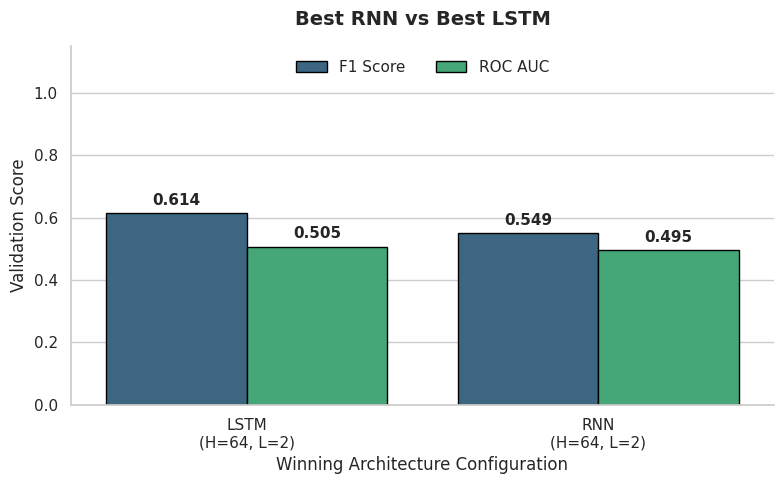

In [ ]:
#cell 12
def plot_model_comparison(hp_df):
    # 1. Identify the "Champions" (Best RNN and Best LSTM based on F1)
    best_idx = hp_df.groupby('model')['val_f1'].idxmax()
    best_models = hp_df.loc[best_idx].copy()
    
    # 2. Create informative labels 
    # (e.g., "LSTM (H=128, L=2)" so we see the winning config)
    best_models['config_label'] = best_models.apply(
        lambda x: f"{x['model'].upper()}\n(H={x['hidden_dim']}, L={x['num_layers']})", axis=1
    )
    
    # 3. Prepare data for plotting (Melt F1 and ROC together)
    # This allows us to plot them side-by-side
    plot_data = best_models.melt(
        id_vars='config_label', 
        value_vars=['val_f1', 'val_roc'], 
        var_name='Metric', 
        value_name='Score'
    )
    # Rename for cleaner legend
    plot_data['Metric'] = plot_data['Metric'].replace({
        'val_f1': 'F1 Score', 
        'val_roc': 'ROC AUC'
    })
    
    # 4. Plot
    plt.figure(figsize=(8, 5))
    
    # Grouped Bar Plot
    ax = sns.barplot(
        data=plot_data, 
        x='config_label', 
        y='Score', 
        hue='Metric', 
        palette='viridis', 
        edgecolor='black',  # Adds crisp border
        linewidth=1
    )
    
    # 5. Add bold numbers on top
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=4, fontweight='bold', fontsize=11)
    
    # 6. Styling
    plt.ylim(0, 1.15) # Extra headroom for legend/labels
    plt.title('Best RNN vs Best LSTM', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Winning Architecture Configuration', fontsize=12)
    plt.ylabel('Validation Score', fontsize=12)
    
    # Place legend nicely on top
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False)
    
    sns.despine() # Removes top and right borders for a cleaner look
    plt.tight_layout()
    plt.show()

plot_model_comparison(hp_df)

In [ ]:
# Cell 13: pick best config from hp_results and retrain on full dataset with full MAX_LEN
best = max(hp_results, key=lambda r: r['val_f1'])
best_cfg = best['config']
# print("Best (fast-search) config:", best_cfg)  # silenced

# build full model according to best_cfg
if best_cfg['model'] == 'rnn':
    final_model = SimpleRNNClassifier(vocab_size=len(vocab.itos),
                                      emb_dim=best_cfg['emb_dim'],
                                      hidden_dim=best_cfg['hidden_dim'],
                                      num_layers=best_cfg['num_layers'],
                                      dropout=best_cfg['dropout'],
                                      pad_idx=vocab.pad_index)
else:
    final_model = LSTMClassifier(vocab_size=len(vocab.itos),
                                 emb_dim=best_cfg['emb_dim'],
                                 hidden_dim=best_cfg['hidden_dim'],
                                 num_layers=best_cfg['num_layers'],
                                 bidirectional=best_cfg['bidirectional'],
                                 dropout=best_cfg['dropout'],
                                 pad_idx=vocab.pad_index)

# Train final model on full train set, validate on full val set
final_model, final_hist = train_model(final_model, train_loader, val_loader, epochs=NUM_EPOCHS_FINAL, lr=best_cfg['lr'], device=DEVICE, verbose=True)
plot_training(final_hist, title="Final Model Training")

# Evaluate on test
test_metrics = evaluate_model(final_model, test_loader, DEVICE)

# Nicely formatted metrics print
keys = ['loss','acc','precision','recall','f1','roc_auc']
print("Test metrics (best final model):")
for k in keys:
    print(f"  {k:>9}: {test_metrics[k]:.4f}")

# Plots
plot_confusion_matrix(test_metrics['trues'], test_metrics['preds'], title="Final Model Test Confusion Matrix")
plot_roc(test_metrics['trues'], test_metrics['probs'], title="Final Model Test ROC")

# Save final model
torch.save(final_model.state_dict(), os.path.join(OUTPUT_DIR, "final_best_model.pt"))
print(f"Saved final model to {os.path.join(OUTPUT_DIR, 'final_best_model.pt')} and {os.path.join(OUTPUT_DIR, 'hp_search_summary.csv')}")


Epoch 1/20 train_loss=0.5794 val_loss=0.4205 val_f1=0.8357 time=6.4s
Epoch 2/20 train_loss=0.3522 val_loss=0.2859 val_f1=0.9088 time=6.0s
Epoch 2/20 train_loss=0.3522 val_loss=0.2859 val_f1=0.9088 time=6.0s
Epoch 3/20 train_loss=0.2397 val_loss=0.2325 val_f1=0.9143 time=6.5s
Epoch 3/20 train_loss=0.2397 val_loss=0.2325 val_f1=0.9143 time=6.5s
Epoch 4/20 train_loss=0.2141 val_loss=0.1790 val_f1=0.9474 time=6.8s
Epoch 4/20 train_loss=0.2141 val_loss=0.1790 val_f1=0.9474 time=6.8s
Epoch 5/20 train_loss=0.1772 val_loss=0.1967 val_f1=0.9270 time=6.9s
Epoch 5/20 train_loss=0.1772 val_loss=0.1967 val_f1=0.9270 time=6.9s
Epoch 6/20 train_loss=0.1314 val_loss=0.1407 val_f1=0.9669 time=6.4s
Epoch 6/20 train_loss=0.1314 val_loss=0.1407 val_f1=0.9669 time=6.4s
Epoch 7/20 train_loss=0.1041 val_loss=0.1400 val_f1=0.9662 time=6.3s
Epoch 7/20 train_loss=0.1041 val_loss=0.1400 val_f1=0.9662 time=6.3s
Epoch 8/20 train_loss=0.1015 val_loss=0.1154 val_f1=0.9732 time=6.4s
Epoch 8/20 train_loss=0.1015 val_l

KeyboardInterrupt: 

In [ ]:

# 1. Compile the Data
report = {
    'dataset_size': len(df),
    'vocab_size': len(vocab.itos),
    'max_len': MAX_LEN,
    'best_cfg': best_cfg,
    'test_metrics': {k: float(test_metrics[k]) for k in ['loss','acc','precision','recall','f1','roc_auc']}
}

# 2. Print Formatted Report
print("\n" + "="*50)
print(f"{'LAB 6: RNN vs LSTM - FINAL REPORT':^50}")
print("="*50)

print(f"\n{'--- DATASET CONFIGURATION ---':^50}")
print(f"Total Samples : {report['dataset_size']:,}")
print(f"Vocabulary Size : {report['vocab_size']:,}")
print(f"Max Seq Length : {report['max_len']}")

print(f"\n{'--- BEST HYPERPARAMETERS ---':^50}")
for key, value in report['best_cfg'].items():
    # Capitalize keys and format values for readability
    print(f"{key.replace('_', ' ').title():<20} : {value}")

print(f"\n{'--- FINAL TEST METRICS ---':^50}")
metrics = report['test_metrics']
print(f"{'Accuracy':<20} : {metrics['acc']:.4%}")
print(f"{'Precision':<20} : {metrics['precision']:.4f}")
print(f"{'Recall':<20} : {metrics['recall']:.4f}")
print(f"{'F1 Score':<20} : {metrics['f1']:.4f}")
print(f"{'ROC AUC':<20} : {metrics['roc_auc']:.4f}")
print(f"{'Test Loss':<20} : {metrics['loss']:.4f}")

print("="*50 + "\n")



        LAB 6: RNN vs LSTM - FINAL REPORT         

          --- DATASET CONFIGURATION ---           
Total Samples : 38,646
Vocabulary Size : 61,532
Max Seq Length : 300

           --- BEST HYPERPARAMETERS ---           
Model                : lstm
Emb Dim              : 50
Hidden Dim           : 64
Num Layers           : 2
Bidirectional        : False
Dropout              : 0.0
Lr                   : 0.0005

            --- FINAL TEST METRICS ---            
Accuracy             : 98.2928%
Precision            : 0.9740
Recall               : 0.9885
F1 Score             : 0.9812
ROC AUC              : 0.9959
Test Loss            : 0.1132

